### 1. Wczytanie danych

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import aseegg as ag 
import numpy as np
import random

In [10]:
df = pd.read_csv("ganglion_4ch_2025-12-04_12-28-43.csv")

In [11]:
df

,time,ch1,ch2,ch3,ch4
0,1.764848e+09,-214.864732,-145.764471,-153.408826,-148.591835
1,1.764848e+09,37.335421,-424.308480,-426.350465,-433.845224
2,1.764848e+09,-12.188334,3.588434,2.036376,0.906926
3,1.764848e+09,-206.872566,-151.997014,-160.688541,-154.764540
4,1.764848e+09,-176.130588,-592.373974,-604.304255,-599.378806
...,...,...,...,...,...
7643,1.764848e+09,137.057984,1335.937143,1335.379898,1341.062676
7644,1.764848e+09,115.972428,1320.252003,1318.662545,1316.641129
7645,1.764848e+09,304.418507,1006.298621,1008.280768,1005.511372
7646,1.764848e+09,335.332520,1039.550071,1049.946993,1047.712403


### 2. Utworzenie sygnału w dziedzinie czasu

In [12]:
len(df["ch1"]) #liczba próbek sygnału

7648

In [13]:
len(df["ch1"])/200 #liczba próbek sygnału : częstotliwość próbkowania 200Hz; całkowity czas trwania sygnału w sekundach

38.24

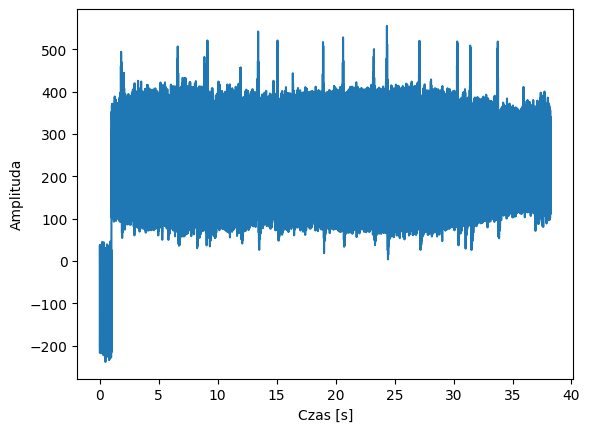

In [14]:
t_axis = np.linspace(0, 38.24, len(df["ch1"])) #sygnał z elektrody "ch1"; czas w sekundach dla każdej próbki sygnału
plt.plot(t_axis, df["ch1"])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.show() #wykres w dziedzinie czasu

### 3. Utworzenie sygnału w dziedzinie częstotliwości

Text(0, 0.5, 'Amplituda')

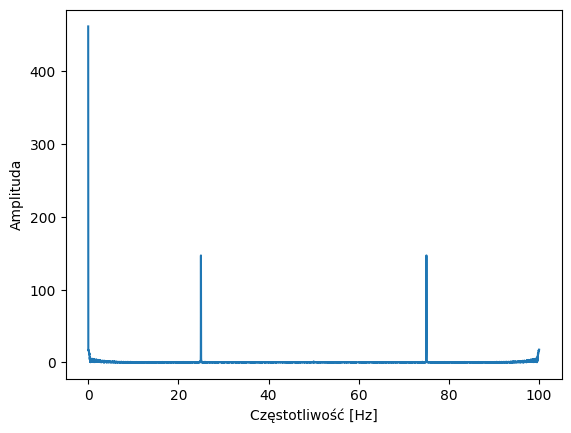

In [15]:
ffted = ag.FFT(df["ch1"]) #jak samo df to dla wszystkich sygnalow
f_axis = np.linspace(0, 100, len(ffted)) #100 bo fs (czestotliwosc probkowania) : 2 = maksymalna czestotliwosc (tutaj 100)
plt.plot(f_axis,ffted)
#w wykresie czestotliwosci
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")

Text(0, 0.5, 'Amplituda')

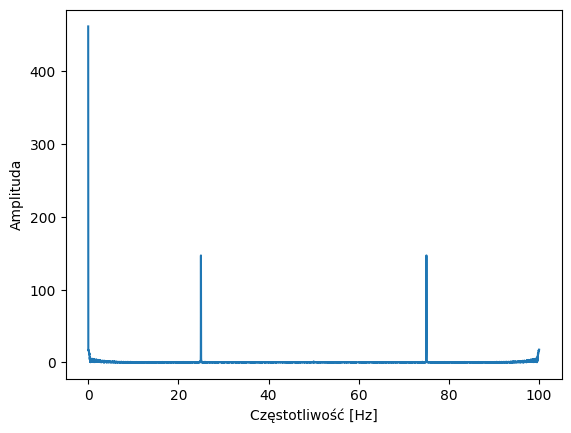

In [16]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted) 
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")

### 4. Wskazanie zakłóceń

(-10.0, 500.0)

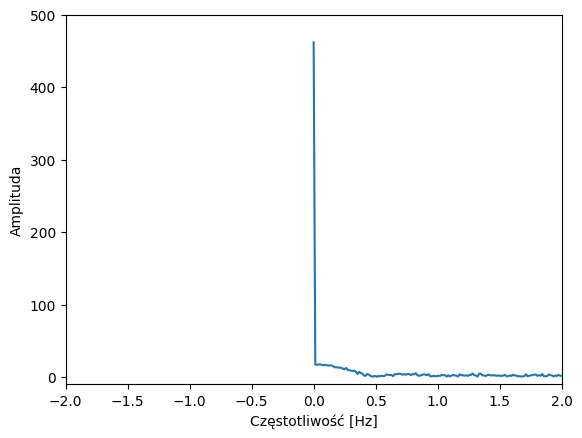

In [17]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 1
plt.xlim([-2,2])
plt.ylim([-10,500])

(-10.0, 150.0)

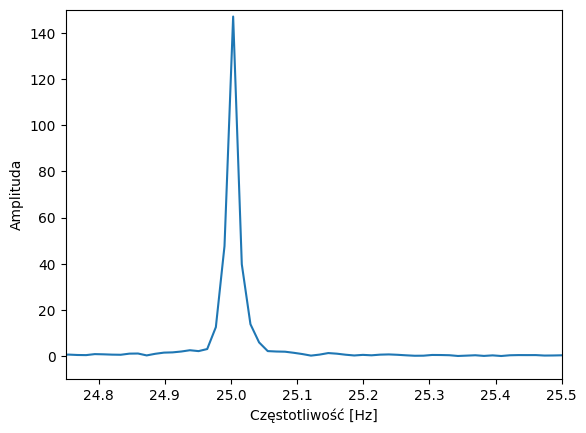

In [18]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 2
plt.xlim([24.75,25.50])
plt.ylim([-10,150])

(-10.0, 150.0)

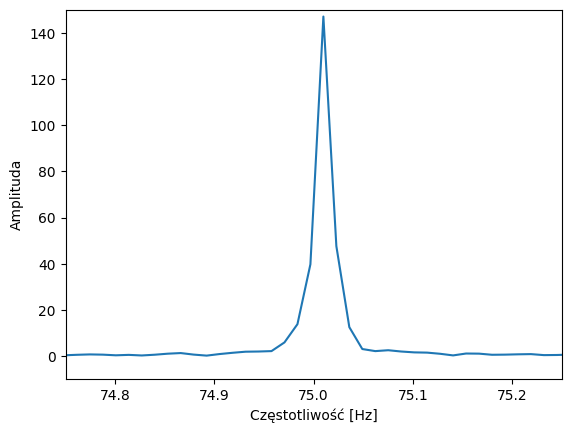

In [19]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 3
plt.xlim([74.75,75.25])
plt.ylim([-10,150])

### 5. Usunięcie zakłóceń (filtracja)

Text(0, 0.5, '[uV]')

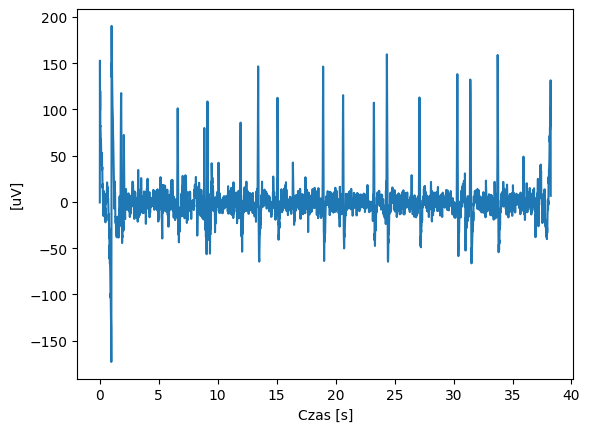

In [20]:
zaklocenie1 = df["ch1"].values
filtracja1 = ag.gornoprzepustowy(zaklocenie1,200,1) #usuniecie pierwszego zaklocenia
filtracja2 = ag.pasmowozaporowy(filtracja1,200,48,52) #usuniecie drugiego zaklocenia
filtracja3 = ag.pasmowoprzepustowy(filtracja2,200,1,40) #usuniecie trzeciego zaklocenia

t_axis = np.linspace(0, len(filtracja3)/200, len(filtracja3))
plt.plot(t_axis,filtracja3)
plt.xlabel('Czas [s]')
plt.ylabel('[uV]')

(-70.0, 150.0)

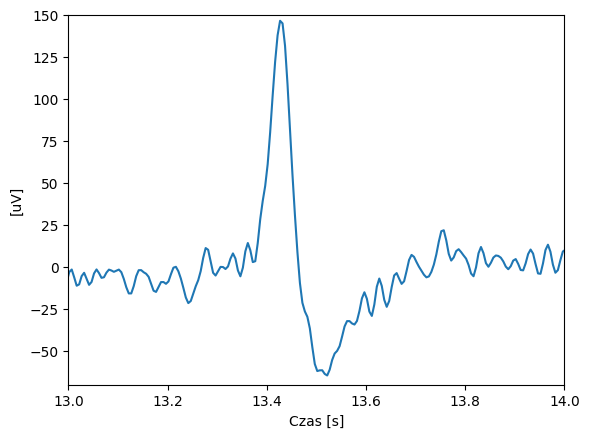

In [21]:
t_axis = np.linspace(0, len(filtracja3)/200, len(filtracja3))
plt.plot(t_axis,filtracja3)
plt.xlabel('Czas [s]')
plt.ylabel('[uV]')
plt.xlim([13,14])
plt.ylim([-70,150])

### 6. Epokowanie (względem triggera - moment mrugnięcia)